# Process Discovery Results Summary

This notebook summarizes the second experimental part of the thesis: the effect of data quality degradation on process discovery using the BPI Challenge 2019 event log.

It uses the results from the 1000-case and 2000-case experiments and focuses only on the most useful tables and plots, so that the analysis remains readable.


## What this notebook shows

The notebook answers four main questions:

1. Did all experimental runs finish successfully?
2. What is the baseline behavior of each miner?
3. Which degradation dimensions affect model quality and complexity the most?
4. Do the 1000-case and 2000-case experiments show similar trends?

The notebook intentionally avoids too many plots. The goal is clarity, not visual overload.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# This works whether the notebook is opened from the project root or from a notebooks/ folder.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "experiments").exists() and (PROJECT_ROOT.parent / "experiments").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "experiments" / "process_discovery" / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "experiments" / "process_discovery" / "results" / "figures" / "summary_notebook"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PATH_1000 = METRICS_DIR / "discovery_results_1000_with_fitness.csv"
PATH_2000 = METRICS_DIR / "discovery_results_2000_with_fitness.csv"

print("Project root:", PROJECT_ROOT)
print("1000-case results:", PATH_1000)
print("2000-case results:", PATH_2000)


Project root: C:\Users\User\PycharmProjects\PM Data Quality
1000-case results: C:\Users\User\PycharmProjects\PM Data Quality\experiments\process_discovery\results\metrics\discovery_results_1000_with_fitness.csv
2000-case results: C:\Users\User\PycharmProjects\PM Data Quality\experiments\process_discovery\results\metrics\discovery_results_2000_with_fitness.csv


## 1. Load and validate results

The original PM4Py fitness field was not directly stored as a flat numeric column. For this reason, the CSVs used here include `fitness_reconstructed`, which is used as the fitness metric in the analysis.


In [2]:
QUALITY_METRICS = [
    "fitness",
    "precision",
    "generalization",
    "simplicity",
    "average_score",
]

STRUCTURAL_METRICS = [
    "places",
    "transitions",
    "visible_transitions",
    "hidden_transitions",
    "arcs",
    "activities_after",
]

DIMENSIONS = ["accuracy", "completeness", "consistency", "timeliness"]


def load_results(path: Path, sample_size: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["sample_size"] = sample_size

    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    # Use reconstructed fitness as the main fitness metric.
    df["fitness"] = pd.to_numeric(df["fitness_reconstructed"], errors="coerce")

    numeric_cols = [
        "degradation_level",
        "repetition",
        *QUALITY_METRICS,
        *STRUCTURAL_METRICS,
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


df_1000 = load_results(PATH_1000, "1000 cases")
df_2000 = load_results(PATH_2000, "2000 cases")
df = pd.concat([df_1000, df_2000], ignore_index=True)

summary = (
    df.groupby("sample_size")
    .agg(
        rows=("dataset", "size"),
        miners=("miner", "nunique"),
        dimensions=("dimension", "nunique"),
        repetitions=("repetition", "max"),
        failed_runs=("status", lambda s: (s != "ok").sum() if "status" in df.columns else 0),
    )
    .reset_index()
)

summary


,sample_size,rows,miners,dimensions,repetitions,failed_runs
0,1000 cases,183,3,5,5,0
1,2000 cases,111,3,5,3,0


## 2. Baseline comparison

This table shows how the three discovery algorithms behave on the non-degraded baseline logs.


In [3]:
baseline_table = (
    df[df["dimension"] == "baseline"]
    .groupby(["sample_size", "miner"], as_index=False)[QUALITY_METRICS + ["places", "transitions", "arcs"]]
    .mean()
)

baseline_table.round(3)


,sample_size,miner,fitness,precision,generalization,simplicity,average_score,places,transitions,arcs
0,1000 cases,alpha,0.323,0.239,0.692,0.662,0.479,17.0,30.0,59.0
1,1000 cases,heuristics,0.955,0.642,0.543,0.498,0.660,55.0,108.0,245.0
2,1000 cases,inductive,1.000,0.262,0.773,0.621,0.664,58.0,86.0,188.0
3,2000 cases,alpha,0.300,0.245,0.695,0.600,0.460,20.0,34.0,72.0
4,2000 cases,heuristics,0.926,0.688,0.535,0.484,0.658,73.0,137.0,322.0
5,2000 cases,inductive,1.000,0.278,0.788,0.625,0.673,66.0,97.0,212.0


Main reading:

- The Inductive Miner is the most stable in terms of fitness.
- The Heuristics Miner usually achieves better precision, but with larger models.
- The Alpha Miner is less suitable for this complex real-life log, especially in terms of fitness and precision.


## 3. Prepare aggregated results

For plotting, the baseline rows are copied to each degradation dimension as level 0. This makes it possible to display 0%, 10%, 20% and 30% in the same plot.


In [4]:
def add_baseline_to_each_dimension(input_df: pd.DataFrame) -> pd.DataFrame:
    baseline_df = input_df[input_df["dimension"] == "baseline"].copy()
    degraded_df = input_df[input_df["dimension"] != "baseline"].copy()

    expanded_baseline_rows = []
    for dimension in DIMENSIONS:
        temp = baseline_df.copy()
        temp["dimension"] = dimension
        temp["degradation_level"] = 0
        temp["repetition"] = 0
        expanded_baseline_rows.append(temp)

    expanded_baseline_df = pd.concat(expanded_baseline_rows, ignore_index=True)
    return pd.concat([expanded_baseline_df, degraded_df], ignore_index=True)


plot_ready_df = add_baseline_to_each_dimension(df)

agg = (
    plot_ready_df
    .groupby(["sample_size", "dimension", "degradation_level", "miner"], as_index=False)[QUALITY_METRICS + STRUCTURAL_METRICS]
    .mean()
)

agg.head()


,sample_size,dimension,degradation_level,miner,fitness,precision,generalization,simplicity,average_score,places,transitions,visible_transitions,hidden_transitions,arcs,activities_after
0,1000 cases,accuracy,0,alpha,0.322573,0.238540,0.692341,0.661972,0.478856,17.0,30.0,30.0,0.0,59.0,30.0
1,1000 cases,accuracy,0,heuristics,0.955364,0.641592,0.542696,0.498471,0.659531,55.0,108.0,30.0,78.0,245.0,30.0
2,1000 cases,accuracy,0,inductive,1.000000,0.262234,0.773352,0.620690,0.664069,58.0,86.0,30.0,56.0,188.0,30.0
3,1000 cases,accuracy,10,alpha,0.234442,0.977607,0.845350,0.266929,0.581082,20.2,30.0,30.0,0.0,120.0,30.0
4,1000 cases,accuracy,10,heuristics,0.842911,0.782199,0.417224,0.421383,0.615930,126.4,310.6,30.0,280.6,737.2,30.0


## 4. Effect at 30% degradation

The following table compares the 30% degradation level against the baseline. The values are averaged over the three miners.


In [5]:
baseline_ref = (
    agg[agg["degradation_level"] == 0]
    [["sample_size", "dimension", "miner", "average_score", "arcs", "activities_after"]]
    .rename(
        columns={
            "average_score": "baseline_average_score",
            "arcs": "baseline_arcs",
            "activities_after": "baseline_activities",
        }
    )
)

level_30 = agg[agg["degradation_level"] == 30].copy()

effects_30 = level_30.merge(
    baseline_ref,
    on=["sample_size", "dimension", "miner"],
    how="left",
)

effects_30["average_score_delta"] = effects_30["average_score"] - effects_30["baseline_average_score"]
effects_30["arcs_pct_change"] = 100 * (effects_30["arcs"] - effects_30["baseline_arcs"]) / effects_30["baseline_arcs"]
effects_30["activities_pct_change"] = 100 * (effects_30["activities_after"] - effects_30["baseline_activities"]) / effects_30["baseline_activities"]

effects_30_by_dimension = (
    effects_30
    .groupby(["sample_size", "dimension"], as_index=False)[
        ["average_score_delta", "arcs_pct_change", "activities_pct_change"]
    ]
    .mean()
)

effects_30_by_dimension.round(3)


,sample_size,dimension,average_score_delta,arcs_pct_change,activities_pct_change
0,1000 cases,accuracy,0.037,153.150,0.000
1,1000 cases,completeness,0.018,42.929,-2.000
2,1000 cases,consistency,-0.087,377.479,221.333
3,1000 cases,timeliness,0.010,27.866,0.000
4,2000 cases,accuracy,0.050,174.978,0.000
5,2000 cases,completeness,0.031,26.735,-3.922
6,2000 cases,consistency,-0.097,478.335,249.020
7,2000 cases,timeliness,0.014,19.214,0.000


## 5. Plot 1 - Average score change at 30% degradation

This plot shows whether model quality improves or decreases at the strongest degradation level. Negative values mean that the average score decreased compared to baseline.


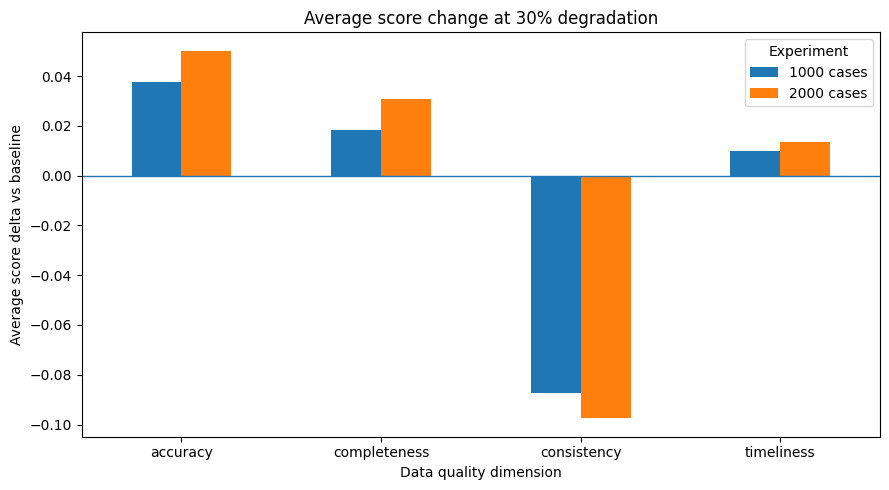

Saved: C:\Users\User\PycharmProjects\PM Data Quality\experiments\process_discovery\results\figures\summary_notebook\average_score_delta_30_by_dimension.png


In [6]:
score_pivot = effects_30_by_dimension.pivot(
    index="dimension",
    columns="sample_size",
    values="average_score_delta",
).loc[DIMENSIONS]

ax = score_pivot.plot(kind="bar", figsize=(9, 5))
ax.axhline(0, linewidth=1)
ax.set_title("Average score change at 30% degradation")
ax.set_xlabel("Data quality dimension")
ax.set_ylabel("Average score delta vs baseline")
ax.legend(title="Experiment")
plt.xticks(rotation=0)
plt.tight_layout()

output_path = FIGURES_DIR / "average_score_delta_30_by_dimension.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)


## 6. Plot 2 - Structural complexity change at 30% degradation

This plot uses the percentage increase in Petri net arcs as a simple indicator of model complexity.


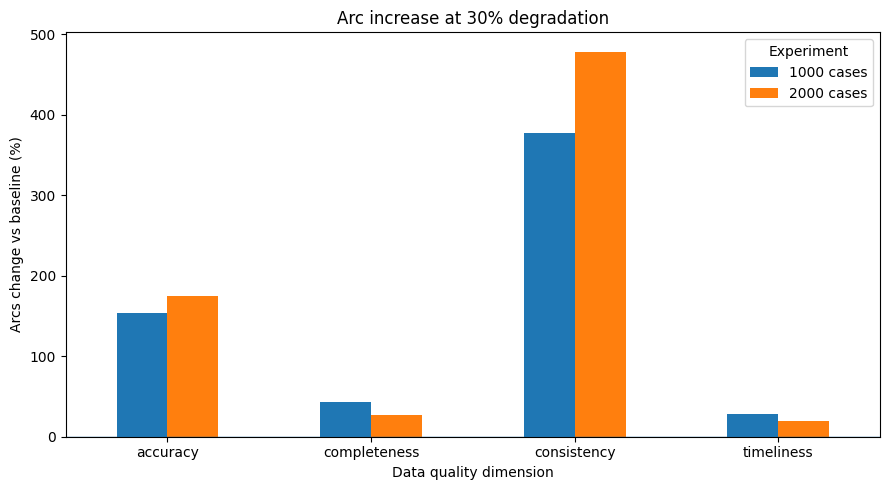

Saved: C:\Users\User\PycharmProjects\PM Data Quality\experiments\process_discovery\results\figures\summary_notebook\arcs_pct_change_30_by_dimension.png


In [7]:
arcs_pivot = effects_30_by_dimension.pivot(
    index="dimension",
    columns="sample_size",
    values="arcs_pct_change",
).loc[DIMENSIONS]

ax = arcs_pivot.plot(kind="bar", figsize=(9, 5))
ax.axhline(0, linewidth=1)
ax.set_title("Arc increase at 30% degradation")
ax.set_xlabel("Data quality dimension")
ax.set_ylabel("Arcs change vs baseline (%)")
ax.legend(title="Experiment")
plt.xticks(rotation=0)
plt.tight_layout()

output_path = FIGURES_DIR / "arcs_pct_change_30_by_dimension.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)


## 7. Plot 3 - Consistency degradation trend

Consistency degradation is the strongest scenario in this experiment. This plot focuses only on consistency, to avoid overloading the notebook with one plot per dimension.


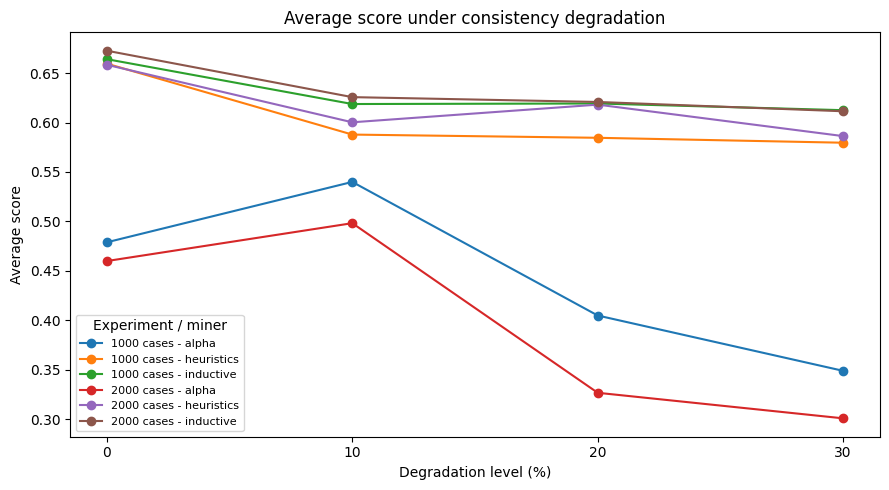

Saved: C:\Users\User\PycharmProjects\PM Data Quality\experiments\process_discovery\results\figures\summary_notebook\consistency_average_score_trend.png


In [8]:
consistency_df = agg[agg["dimension"] == "consistency"].copy()

fig, ax = plt.subplots(figsize=(9, 5))

for (sample_size, miner), part in consistency_df.groupby(["sample_size", "miner"]):
    part = part.sort_values("degradation_level")
    ax.plot(
        part["degradation_level"],
        part["average_score"],
        marker="o",
        label=f"{sample_size} - {miner}",
    )

ax.set_title("Average score under consistency degradation")
ax.set_xlabel("Degradation level (%)")
ax.set_ylabel("Average score")
ax.set_xticks([0, 10, 20, 30])
ax.legend(title="Experiment / miner", fontsize=8)
plt.tight_layout()

output_path = FIGURES_DIR / "consistency_average_score_trend.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)


## 8. Validation: 1000 vs 2000 cases

The 2000-case experiment is used as a validation run. High correlations indicate that the larger experiment confirms the trends observed in the 1000-case experiment.


In [9]:
comparison_base = (
    agg
    .groupby(["sample_size", "dimension", "degradation_level", "miner"], as_index=False)[
        ["fitness", "precision", "generalization", "simplicity", "average_score", "arcs", "transitions"]
    ]
    .mean()
)

comp_1000 = comparison_base[comparison_base["sample_size"] == "1000 cases"].drop(columns="sample_size")
comp_2000 = comparison_base[comparison_base["sample_size"] == "2000 cases"].drop(columns="sample_size")

merged_comp = comp_1000.merge(
    comp_2000,
    on=["dimension", "degradation_level", "miner"],
    suffixes=("_1000", "_2000"),
)

corr_rows = []
for metric in ["fitness", "precision", "generalization", "simplicity", "average_score", "arcs", "transitions"]:
    corr_rows.append(
        {
            "metric": metric,
            "correlation_1000_vs_2000": merged_comp[f"{metric}_1000"].corr(merged_comp[f"{metric}_2000"]),
        }
    )

correlation_table = pd.DataFrame(corr_rows)
correlation_table.round(3)


,metric,correlation_1000_vs_2000
0,fitness,0.997
1,precision,0.994
2,generalization,0.995
3,simplicity,0.939
4,average_score,0.989
5,arcs,0.991
6,transitions,0.995


## 9. Main conclusions

The main conclusions from the two experimental runs are:

1. The 2000-case experiment confirms the main trends observed in the 1000-case experiment.
2. Consistency degradation has the strongest negative effect on the discovered process models.
3. Accuracy and completeness degradation do not always reduce the average score, because the models are discovered and evaluated on the degraded logs themselves.
4. Structural metrics are necessary because quality metrics alone may hide increases in model complexity.
5. The Inductive Miner is the most stable overall, while the Heuristics Miner often achieves higher precision at the cost of larger models.

The key methodological point is that degraded data can produce models that still appear acceptable according to some evaluation metrics, while their structural complexity increases significantly.
